# Khai báo các thư viện cần thiết (Import Required Libraries)

In [1]:
# Xử lý dữ liệu và tính toán
import pandas as pd
import numpy as np

# Trực quan hóa
import matplotlib.pyplot as plt
import matplotlib.lines as mlines

# Thư viện statsmodels (phân tích dãy số thời gian)
import statsmodels
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Thư viện sklearn
import sklearn
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Các mô hình ML
import xgboost as xgb
import lightgbm as lgb
from lightgbm import early_stopping, log_evaluation
import catboost
from catboost import CatBoostRegressor, Pool

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

In [2]:
print("Phiên bản thư viện đang sử dụng:")
print(f"pandas: {pd.__version__}")
print(f"numpy: {np.__version__}")
print(f"matplotlib: {plt.matplotlib.__version__}")
print(f"statsmodels: {statsmodels.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"xgboost: {xgb.__version__}")
print(f"lightgbm: {lgb.__version__}")
print(f"catboost: {catboost.__version__}")

Phiên bản thư viện đang sử dụng:
pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
statsmodels: 0.14.4
scikit-learn: 1.6.1
xgboost: 3.0.5
lightgbm: 4.6.0
catboost: 1.2.8


# Tổng quan về dữ liệu (Overview)

In [3]:
base_path = os.path.join("data", "unprocessed")

holidays_events = pd.read_csv(os.path.join(base_path, "holidays_events.csv"))
oil = pd.read_csv(os.path.join(base_path, "oil.csv"))
stores = pd.read_csv(os.path.join(base_path, "stores.csv"))
train_test = pd.read_csv(os.path.join(base_path, "train_test.csv"))
transactions = pd.read_csv(os.path.join(base_path, "transactions.csv"))

In [4]:
# Danh sách các datasets
datasets = {
    "holidays_events": holidays_events,
    "oil": oil,
    "stores": stores,
    "train_test": train_test,
    "transactions": transactions
}

In [5]:
# In thông tin chi tiết từng dataset (5 dòng đầu tiên và kiểu dữ liệu)
for name, df in datasets.items():
    print(f"\nDataset: {name}")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("Overview:")
    print(df.head())
    print("Datatypes:")
    print(df.dtypes)


Dataset: holidays_events
Shape: 350 rows, 6 columns
Overview:
         date     type    locale locale_name                    description  \
0  2012-03-02  Holiday     Local       Manta             Fundacion de Manta   
1  2012-04-01  Holiday  Regional    Cotopaxi  Provincializacion de Cotopaxi   
2  2012-04-12  Holiday     Local      Cuenca            Fundacion de Cuenca   
3  2012-04-14  Holiday     Local    Libertad      Cantonizacion de Libertad   
4  2012-04-21  Holiday     Local    Riobamba      Cantonizacion de Riobamba   

   transferred  
0        False  
1        False  
2        False  
3        False  
4        False  
Datatypes:
date           object
type           object
locale         object
locale_name    object
description    object
transferred      bool
dtype: object

Dataset: oil
Shape: 1218 rows, 2 columns
Overview:
         date  dcoilwtico
0  2013-01-01         NaN
1  2013-01-02       93.14
2  2013-01-03       92.97
3  2013-01-04       93.12
4  2013-01-07       9

## Định dạng lại kiểu dữ liệu (Data Type Normalization)

In [6]:
# holidays_events
holidays_events['date'] = pd.to_datetime(holidays_events['date'])
for col in ['type', 'locale', 'locale_name']:
    holidays_events[col] = holidays_events[col].astype('category')

# oil
oil['date'] = pd.to_datetime(oil['date'])

# stores
for col in ['store_nbr','city','state','type','cluster']:
    stores[col] = stores[col].astype('category')

# train_test
train_test['date'] = pd.to_datetime(train_test['date'])
for col in ['id','store_nbr','family']:
    train_test[col] = train_test[col].astype('category')
    
# transactions
transactions['date'] = pd.to_datetime(transactions['date'])
transactions['store_nbr'] = transactions['store_nbr'].astype('category')

In [7]:
# Kiểm tra lại
for name, df in datasets.items():
    print(f"\nDataset: {name}")
    print("Datatypes:")
    print(df.dtypes)


Dataset: holidays_events
Datatypes:
date           datetime64[ns]
type                 category
locale               category
locale_name          category
description            object
transferred              bool
dtype: object

Dataset: oil
Datatypes:
date          datetime64[ns]
dcoilwtico           float64
dtype: object

Dataset: stores
Datatypes:
store_nbr    category
city         category
state        category
type         category
cluster      category
dtype: object

Dataset: train_test
Datatypes:
id                   category
date           datetime64[ns]
store_nbr            category
family               category
sales                 float64
onpromotion             int64
dtype: object

Dataset: transactions
Datatypes:
date            datetime64[ns]
store_nbr             category
transactions             int64
dtype: object


# Phân tích khám phá với dữ liệu ban đầu (EDA of raw data)

## Phân phối của biến sales (Sales Distribution)

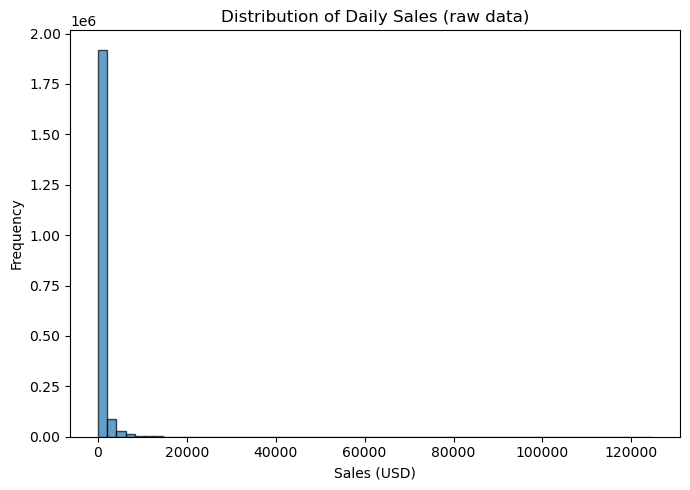

In [8]:
# Loại bỏ NaN và giá trị âm (nếu có)
sales_data = train_test['sales'].dropna()
sales_data = sales_data[sales_data > 0]

# Vẽ histogram cho sales gốc
plt.figure(figsize=(7,5))
plt.hist(sales_data, bins=60, edgecolor='black', alpha=0.7)
plt.title('Distribution of Daily Sales (raw data)')
plt.xlabel('Sales (USD)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

## Xu hướng biến động của giá dầu (dcoilwtico) và doanh thu (sales)

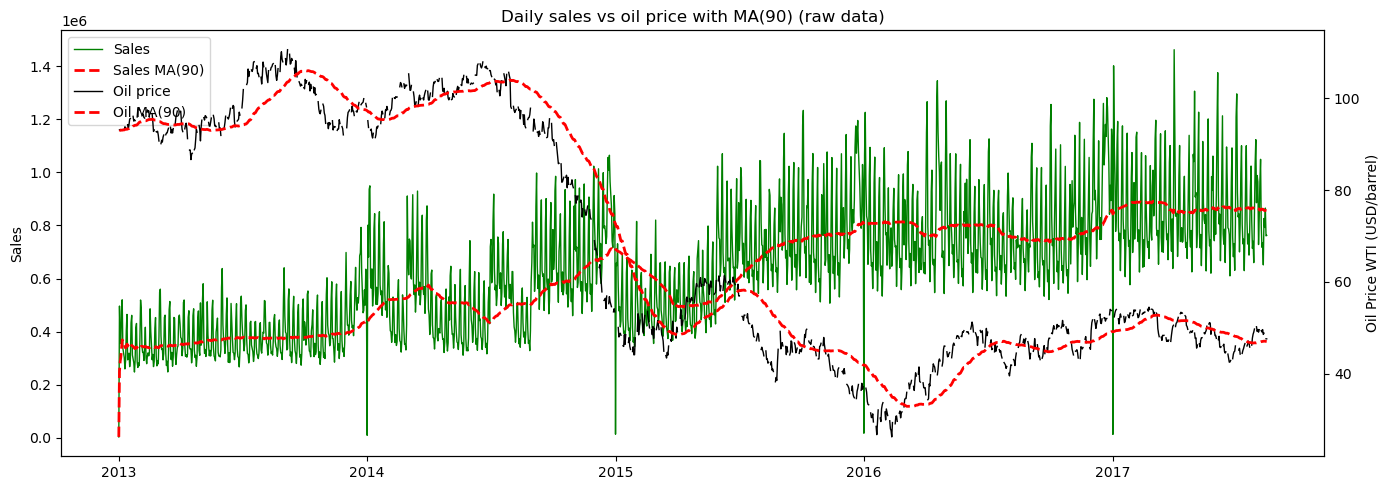

In [9]:
# Tổng sales theo ngày (từ raw data)
sales_daily = (
    train_test[['date', 'sales']]
    .dropna(subset=['date'])
    .groupby('date', as_index=False)['sales'].sum()
)

# Gộp với oil theo ngày
plot_df = sales_daily.merge(oil[['date', 'dcoilwtico']], on='date', how='left').sort_values('date')

# Trend 90 ngày
plot_df['sales_ma_90'] = plot_df['sales'].rolling(90, min_periods=1).mean()
plot_df['oil_ma_90'] = plot_df['dcoilwtico'].rolling(90, min_periods=1).mean()

# Vẽ 2 trục y
fig, ax1 = plt.subplots(figsize=(14,5))

# Sales (gốc + MA)
ax1.plot(plot_df['date'], plot_df['sales'], label='Sales', color='green', linewidth=1)
ax1.plot(plot_df['date'], plot_df['sales_ma_90'], label='Sales MA(90)', color='red', linewidth=2, linestyle='--')
ax1.set_ylabel('Sales')

# Oil (gốc + MA)
ax2 = ax1.twinx()
ax2.plot(plot_df['date'], plot_df['dcoilwtico'], label='Oil price', color='black', linewidth=1)
ax2.plot(plot_df['date'], plot_df['oil_ma_90'], label='Oil MA(90)', color='red', linewidth=2, linestyle='--')
ax2.set_ylabel('Oil Price WTI (USD/barrel)')

# Legend gộp cho cả hai trục
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Daily sales vs oil price with MA(90) (raw data)')
plt.tight_layout()
plt.show()

## Tương quan giữa tổng số sản phẩm khuyến mãi (onpromotion) và tổng doanh thu (sales)

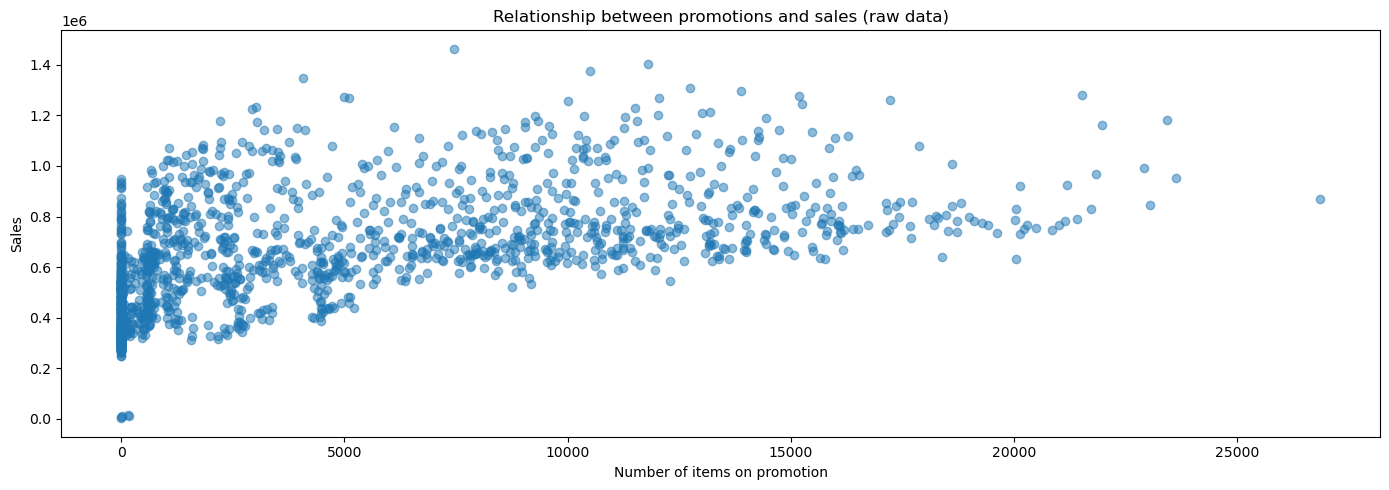

In [10]:
# Gom dữ liệu theo ngày, tính tổng khuyến mãi và tổng doanh thu
promo_sales = (
    train_test.groupby('date', as_index=False)
    .agg({'onpromotion':'sum', 'sales':'sum'})
    .sort_values('date')
)

# Vẽ scatter plot
plt.figure(figsize=(14,5))
plt.scatter(promo_sales['onpromotion'], promo_sales['sales'], alpha=0.5)
plt.title('Relationship between promotions and sales (raw data)')
plt.xlabel('Number of items on promotion')
plt.ylabel('Sales')
plt.tight_layout()
plt.show()

# Số mặt hàng (family) theo từng cửa hàng (store_nbr) 

Tổng số cửa hàng (store_nbr): 54
Tất cả các cửa hàng đều có cùng số lượng mặt hàng: 33


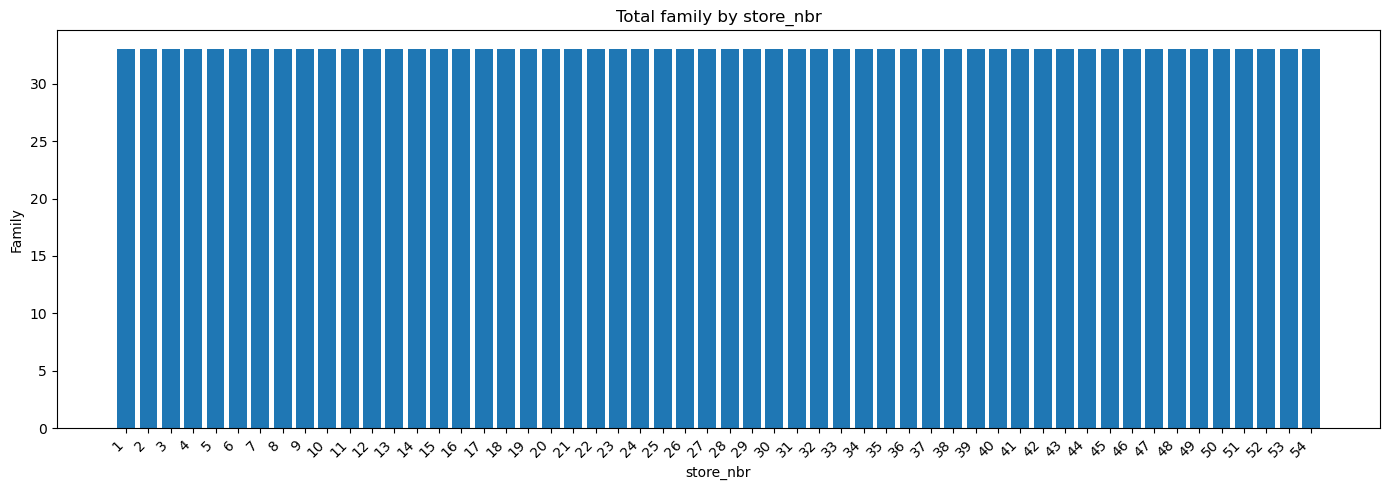

In [11]:
train_summary = train_test.copy()

# Đếm số mặt hàng (family) theo từng cửa hàng
store_family_count = train_summary.groupby('store_nbr')['family'].nunique().reset_index()
store_family_count.columns = ['store_nbr', 'num_families']

# Đếm tổng số cửa hàng
num_stores = store_family_count['store_nbr'].nunique()
print(f"Tổng số cửa hàng (store_nbr): {num_stores}")

# Kiểm tra xem tất cả cửa hàng có số family bằng nhau không
unique_counts = store_family_count['num_families'].unique()

if len(unique_counts) == 1:
    print(f"Tất cả các cửa hàng đều có cùng số lượng mặt hàng: {unique_counts[0]}")
else:
    print("Số lượng mặt hàng giữa các cửa hàng không bằng nhau")
    print(f"Min: {store_family_count['num_families'].min()}") 
    print(f"Max: {store_family_count['num_families'].max()}")
    print(store_family_count.sort_values('num_families').head())

# Vẽ
plt.figure(figsize=(14,5))
plt.bar(store_family_count['store_nbr'].astype(str), store_family_count['num_families'])
plt.xticks(rotation=45, ha='right')
plt.xlabel('store_nbr')
plt.ylabel('Family')
plt.title('Total family by store_nbr')
plt.tight_layout()
plt.show()

# Tiền xử lý dữ liệu (Data Pre-processing)

## Kiểm tra dữ liệu thiếu, dữ liệu trùng

In [12]:
def audit_datasets_simple(
    datasets: dict,
    top_n_missing: int = 20,
    dup_sample: int = 5,
    normalize_blank: bool = True # chuyển chuỗi trắng -> NaN trước khi thống kê
):

    for name, df in datasets.items():
        print(f"Dataset: {name}")

        _df = df.copy()
        if normalize_blank:
            _df = _df.replace(r"^\s*$", np.nan, regex=True)

        # Giá trị thiếu
        na_counts = _df.isna().sum()
        na_counts = na_counts[na_counts > 0].sort_values(ascending=False)
        if len(na_counts) == 0:
            print("Không có giá trị NaN")
        else:
            print(f"Cột có NaN:")
            miss_report = pd.DataFrame({"NaN": na_counts})
            print(miss_report.head(top_n_missing))

        # Số dòng trùng
        dup_all = _df.duplicated().sum()
        print(f"Số dòng trùng: {dup_all}")
        if dup_all > 0 and dup_sample > 0:
            print(f"Ví dụ {dup_sample} dòng trùng:")
            print(_df[_df.duplicated(keep=False)].head(dup_sample))

        print()

In [13]:
audit_datasets_simple(
    datasets,
    top_n_missing=20,
    dup_sample=5,
    normalize_blank=True
)

Dataset: holidays_events
Không có giá trị NaN
Số dòng trùng: 0

Dataset: oil
Cột có NaN:
            NaN
dcoilwtico   43
Số dòng trùng: 0

Dataset: stores
Không có giá trị NaN
Số dòng trùng: 0

Dataset: train_test
Không có giá trị NaN
Số dòng trùng: 0

Dataset: transactions
Không có giá trị NaN
Số dòng trùng: 0



## Kiểm tra các giá trị âm

In [14]:
# Hàm kiểm tra giá trị âm 
def check_negative_values(datasets: dict):
    for name, df in datasets.items():
        num_cols = df.select_dtypes(include=[np.number]).columns # Lọc ra các cột number
        neg_cols = {}
        for col in num_cols:
            neg_count = (df[col] < 0).sum()
            if neg_count > 0:
                neg_cols[col] = int(neg_count)
        if len(neg_cols) > 0:
            print(f"Dataset: {name}")
            for col, count in neg_cols.items():
                print(f"Cột '{col}' có {count} giá trị âm")
            print()
        else:
            print(f"Dataset: {name} không có giá trị âm")

In [15]:
# Gọi hàm kiểm tra
check_negative_values(datasets)

Dataset: holidays_events không có giá trị âm
Dataset: oil không có giá trị âm
Dataset: stores không có giá trị âm
Dataset: train_test không có giá trị âm
Dataset: transactions không có giá trị âm


## Xử lý dữ liệu sau sau khi kiểm tra

In [16]:
# Sắp xếp theo ngày 
oil = oil.sort_values('date')

# Fill dữ liệu
oil['dcoilwtico'] = oil['dcoilwtico'].ffill().bfill()

missing_after = oil['dcoilwtico'].isna().sum()
print(f"Số giá trị NaN sau khi fill: {missing_after}")

Số giá trị NaN sau khi fill: 0


## Tạo biến giả (dummy variables) cho ngày lễ/sự kiện (holidays_events)

In [17]:
hol = holidays_events.copy()

# Chỉ giữ ngày lễ cấp quốc gia hoặc vùng miền (bỏ Local)
hol = hol[hol['locale'].isin(['National', 'Regional'])]

# Bỏ các ngày lễ đã được chuyển sang ngày khác (transferred=True)
hol = hol[~((hol['type'] == 'Holiday') & (hol['transferred'] == True))]

# Giữ các loại sự kiện/ngày nghỉ có tác động
valid_types = ['Holiday', 'Transfer', 'Bridge', 'Additional', 'Event', 'Work Day']
hol = hol[hol['type'].isin(valid_types)]

# Tạo biến giả
hol['is_holiday'] = hol['type'].isin(['Holiday', 'Transfer', 'Bridge', 'Additional', 'Event'])
hol['is_workday'] = (hol['type'] == 'Work Day')

# Map phạm vi áp dụng xuống từng store
# National: áp cho tất cả store
hol_nat = hol[hol['locale'] == 'National'][['date', 'is_holiday', 'is_workday']].copy()
hol_nat['key'] = 1
stores_key = stores[['store_nbr']].copy()
stores_key['key'] = 1
nat_store = hol_nat.merge(stores_key, on='key', how='left').drop(columns='key')

# Regional: áp cho các store có city == locale_name
hol_reg = hol[hol['locale'] == 'Regional'][['date', 'locale_name', 'is_holiday', 'is_workday']].copy()
reg_store = hol_reg.merge(
    stores[['store_nbr', 'city']],
    left_on='locale_name', right_on='city',
    how='inner'
).drop(columns=['locale_name', 'city'])

# Gộp và xử lý xung đột trong cùng date-store
hol_store = (
    pd.concat([nat_store, reg_store], ignore_index=True)
      .groupby(['date', 'store_nbr'], as_index=False)
      .agg({'is_holiday': 'max', 'is_workday': 'max'})
)

# Nếu cùng ngày vừa holiday vừa workday -> coi như không nghỉ
hol_store['is_holiday'] = ((hol_store['is_holiday'] == 1) & (hol_store['is_workday'] == 0)).astype('uint8')

# Kết quả cuối cùng để merge với train_test
holidays_store = (
    hol_store[['date', 'store_nbr', 'is_holiday']]
    .sort_values(['date', 'store_nbr'])
    .reset_index(drop=True)
)

# Chuẩn bị dữ liệu trước khi huấn luyện

## Gộp các bộ dữ liệu (Merging Datasets)

In [18]:
merged = train_test.copy()

# Thêm thông tin cửa hàng
merged = merged.merge(stores, on='store_nbr', how='left')

# Thêm số giao dịch theo ngày & cửa hàng
merged = merged.merge(transactions, on=['date','store_nbr'], how='left')

# Thêm giá dầu (theo ngày)
merged = merged.merge(oil, on='date', how='left')

# Thêm ngày lễ theo vùng (chuẩn)
merged = merged.merge(holidays_store, on=['date','store_nbr'], how='left')
merged['is_holiday'] = merged['is_holiday'].fillna(0)

print(merged.head())

  id       date store_nbr      family  sales  onpromotion   city      state  \
0  0 2013-01-01         1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1  1 2013-01-01         1   BABY CARE    0.0            0  Quito  Pichincha   
2  2 2013-01-01         1      BEAUTY    0.0            0  Quito  Pichincha   
3  3 2013-01-01         1   BEVERAGES    0.0            0  Quito  Pichincha   
4  4 2013-01-01         1       BOOKS    0.0            0  Quito  Pichincha   

  type cluster  transactions  dcoilwtico  is_holiday  
0    D      13           NaN       93.14         1.0  
1    D      13           NaN       93.14         1.0  
2    D      13           NaN       93.14         1.0  
3    D      13           NaN       93.14         1.0  
4    D      13           NaN       93.14         1.0  


In [19]:
print(merged.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 13 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id            category      
 1   date          datetime64[ns]
 2   store_nbr     category      
 3   family        category      
 4   sales         float64       
 5   onpromotion   int64         
 6   city          category      
 7   state         category      
 8   type          category      
 9   cluster       category      
 10  transactions  float64       
 11  dcoilwtico    float64       
 12  is_holiday    float64       
dtypes: category(7), datetime64[ns](1), float64(4), int64(1)
memory usage: 253.4 MB
None


## Kiểm tra và xử lý dữ liệu sau khi gộp

In [20]:
# Kiểm tra NaN sau khi gộp
total = len(merged)
na = merged.isna().sum()
na = na[na > 0].sort_values(ascending=False)

if len(na) == 0:
    print("Không còn giá trị NaN sau khi gộp")
else:
    print("Còn NaN sau khi gộp:")
    report = pd.DataFrame({"NaN": na})
    print(report)

Còn NaN sau khi gộp:
                 NaN
dcoilwtico    857142
transactions  245784


In [21]:
# Xử lý cột dầu (dcoilwtico): forward fill, nếu đầu chuỗi vẫn NaN thì backfill
merged['dcoilwtico'] = merged['dcoilwtico'].ffill().bfill()

# Cột transactions: chỗ nào thiếu thì coi như = 0
merged['transactions'] = merged['transactions'].fillna(0)

# Kiểm tra lại
na_cols = merged.isna().sum()
na_cols = na_cols[na_cols > 0]

if len(na_cols) == 0:
    print("Đã fill đầy đủ")
else:
    print("Vẫn còn cột thiếu giá trị:")
    print(na_cols)

Đã fill đầy đủ


In [22]:
print(merged.head())
print(merged.info())

  id       date store_nbr      family  sales  onpromotion   city      state  \
0  0 2013-01-01         1  AUTOMOTIVE    0.0            0  Quito  Pichincha   
1  1 2013-01-01         1   BABY CARE    0.0            0  Quito  Pichincha   
2  2 2013-01-01         1      BEAUTY    0.0            0  Quito  Pichincha   
3  3 2013-01-01         1   BEVERAGES    0.0            0  Quito  Pichincha   
4  4 2013-01-01         1       BOOKS    0.0            0  Quito  Pichincha   

  type cluster  transactions  dcoilwtico  is_holiday  
0    D      13           0.0       93.14         1.0  
1    D      13           0.0       93.14         1.0  
2    D      13           0.0       93.14         1.0  
3    D      13           0.0       93.14         1.0  
4    D      13           0.0       93.14         1.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 13 columns):
 #   Column        Dtype         
---  ------        -----         
 0   id       

# Phân tích khám phá dãy số thời gian của biến sales (EDA of Sales Time Series)

## Phân rã dãy số thời gian (Time Series Decomposion)

In [23]:
# Chuẩn bị chuỗi thời gian tổng theo ngày
daily = (merged.groupby('date')['sales'].sum().sort_index().asfreq('D').fillna(0))

# Phân rã chuỗi (additive, tuần = 7 ngày)
decomp = seasonal_decompose(daily, model='additive', period=7)

### Chuỗi gốc

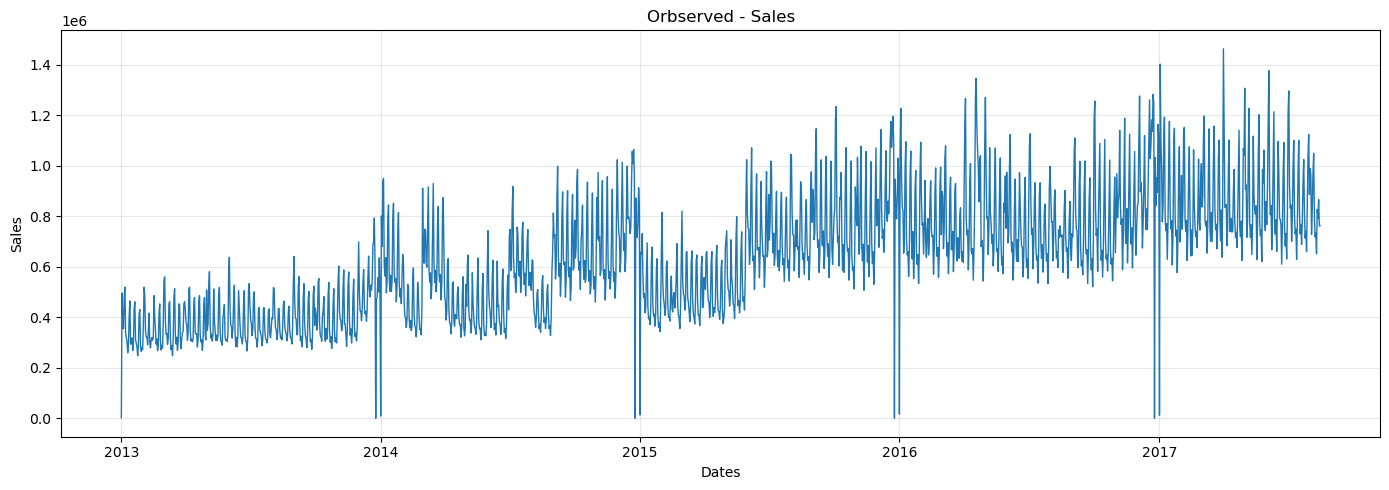

In [24]:
plt.figure(figsize=(14,5))
plt.plot(daily, color='C0', linewidth=1)
plt.title('Orbserved - Sales')
plt.xlabel('Dates')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Xu hướng

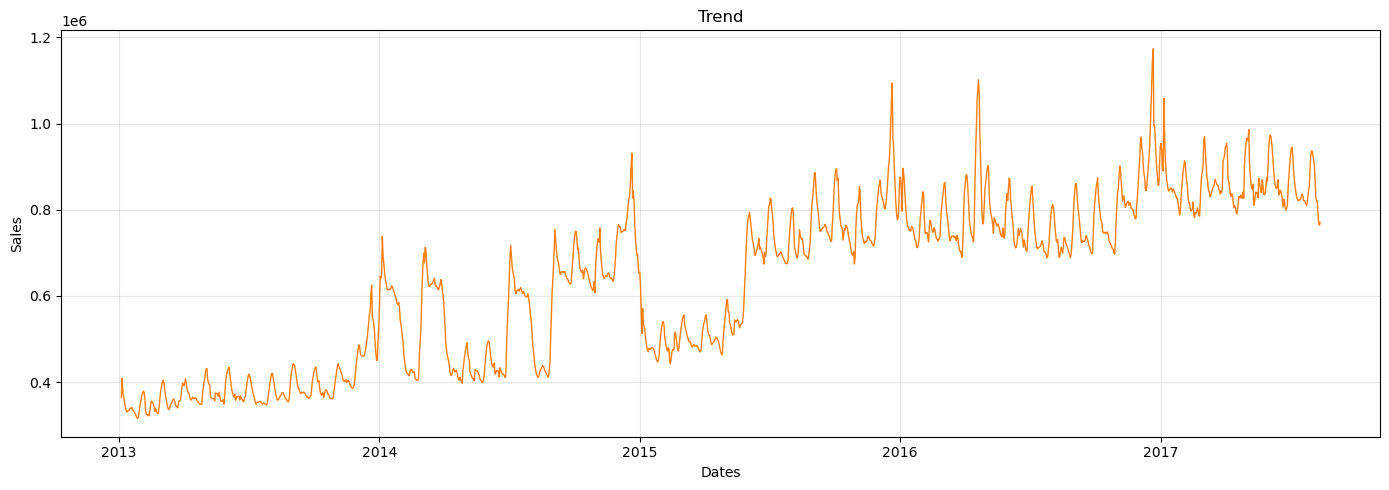

In [25]:
plt.figure(figsize=(14,5))
plt.plot(decomp.trend, color='C1', linewidth=1)
plt.title('Trend')
plt.xlabel('Dates')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Mùa vụ (seasonal)

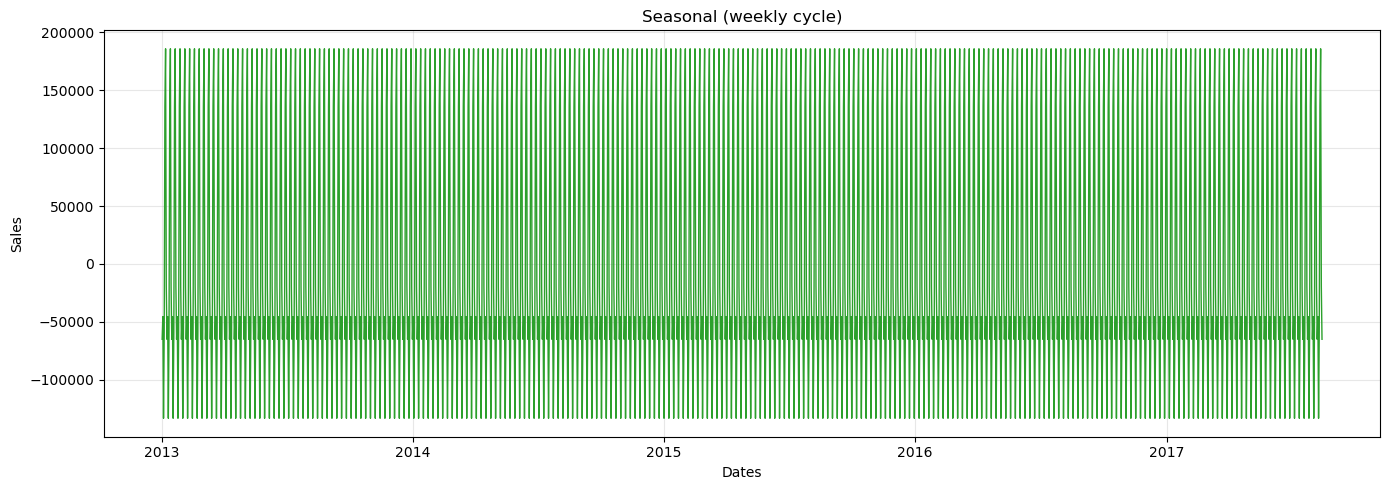

In [26]:
plt.figure(figsize=(14,5))
plt.plot(decomp.seasonal, color='C2', linewidth=1)
plt.title('Seasonal (weekly cycle)')
plt.xlabel('Dates')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Phần dư (residual)

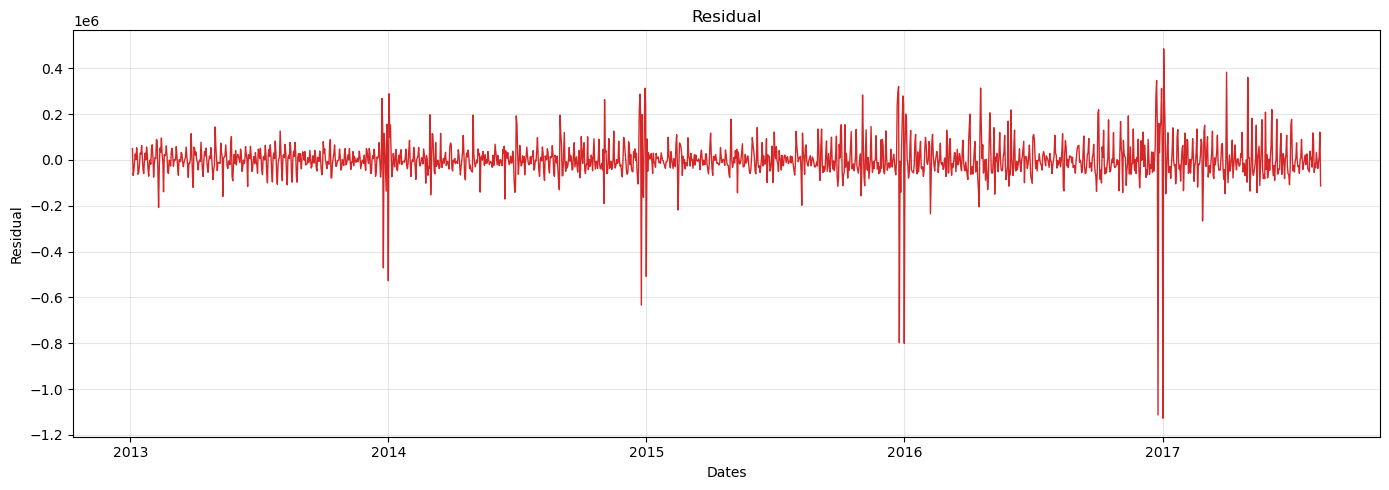

In [27]:
plt.figure(figsize=(14,5))
plt.plot(decomp.resid, color='C3', linewidth=1)
plt.title('Residual')
plt.xlabel('Dates')
plt.ylabel('Residual')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Kiểm định tính dừng (stationary) bằng kiểm định ADF (Augmented Dickey Fuller test) 

In [28]:
result = adfuller(daily)
print(f"ADF statistic: {result[0]:.2f}")
print(f"p-value: {result[1]:.2f}")
print("-> Chuỗi", "dừng" if result[1] < 0.05 else "không dừng")

ADF statistic: -2.57
p-value: 0.10
-> Chuỗi không dừng


ADF Statistic: -11.31
p-value: 0.00
-> Chuỗi sai phân bậc 1 dừng


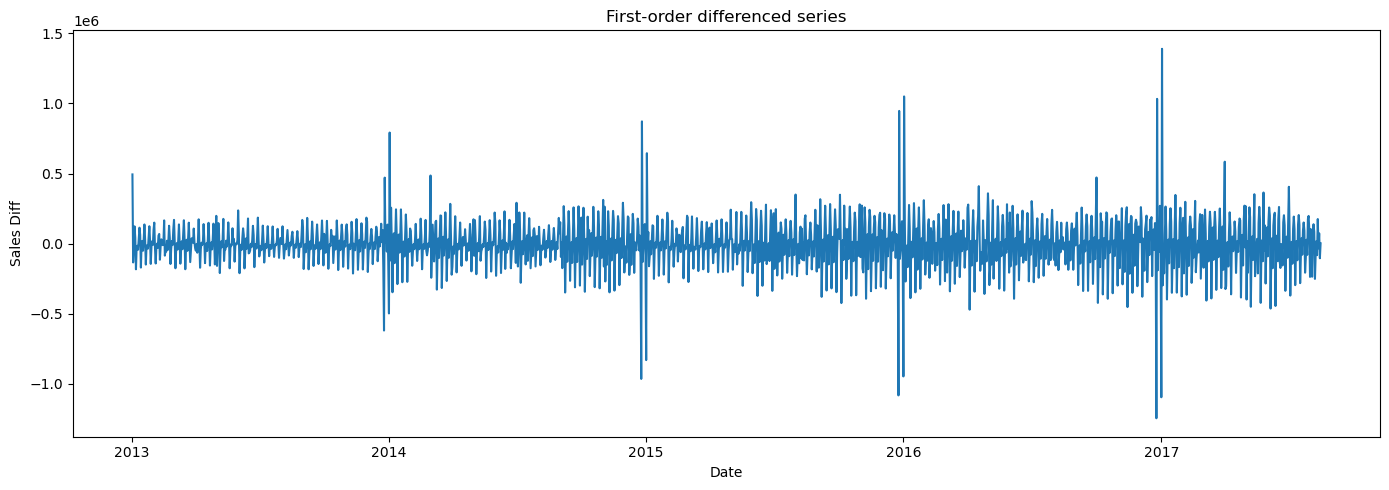

In [29]:
# Lấy sai phân bậc 1
daily_diff = daily.diff().dropna()

# Kiểm định ADF
result = adfuller(daily_diff)
print(f"ADF Statistic: {result[0]:.2f}")
print(f"p-value: {result[1]:.2f}")
print("-> Chuỗi sai phân bậc 1", "dừng" if result[1] < 0.05 else "không dừng")

# Vẽ chuỗi sai phân
plt.figure(figsize=(14,5))
plt.plot(daily_diff)
plt.title("First-order differenced series")
plt.xlabel("Date")
plt.ylabel("Sales Diff")
plt.tight_layout()
plt.show()

## Vẽ biểu đồ tự tương quan (ACF) và tự tương quan riêng phần (PACF)

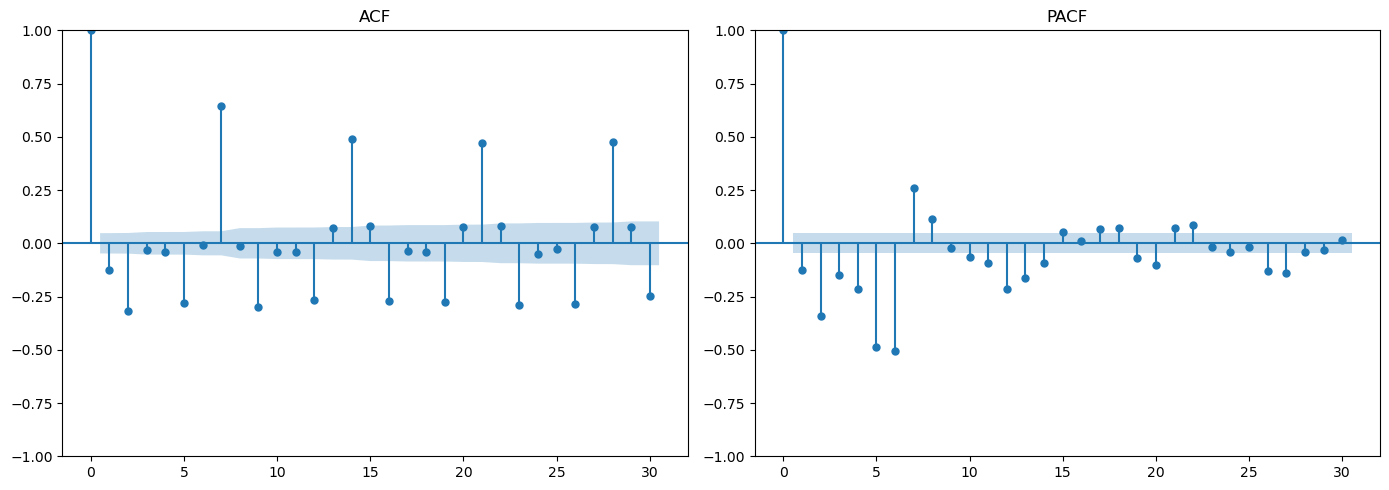

In [30]:
# Vẽ ACF và PACF cho chuỗi sai phân bậc 1
fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_acf(daily_diff, lags=30, ax=axes[0])
axes[0].set_title("ACF")

plot_pacf(daily_diff, lags=30, ax=axes[1])
axes[1].set_title("PACF")

plt.tight_layout()
plt.show()

# Tạo các đặc trưng mới (Feature Engineering)

## Tạo các đặc trưng mới

In [31]:
df = merged.copy()
# Sắp xếp dữ liệu theo thứ tự thời gian của từng cửa hàng và từng nhóm hàng
df = df.sort_values(['store_nbr', 'family', 'date']).reset_index(drop=True)

In [32]:
# Mã hóa các biến dạng chữ (danh mục) thành số để mô hình học được
cat_cols = ['store_nbr', 'family', 'city', 'state', 'type', 'cluster']
encoders = {}
for c in cat_cols:
    le = LabelEncoder()
    df[c] = le.fit_transform(df[c].astype(str))
    encoders[c] = le

In [33]:
# Tạo các đặc trưng về thời gian
# Mục đích: giúp mô hình nhận biết được xu hướng theo ngày, tháng, năm
df['year'] = df['date'].dt.year.astype(int)
df['month'] = df['date'].dt.month.astype(int)
df['dayofweek'] = df['date'].dt.dayofweek.astype(int)  # 0 = Thứ 2, 6 = Chủ nhật
df['dayofmonth'] = df['date'].dt.day.astype(int)
df['weekofyear'] = df['date'].dt.isocalendar().week.astype(int)

In [34]:
# Biến này cho biết ngày đó có phải là cuối tuần không (thứ 7 hoặc chủ nhật)
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)

In [35]:
# Tthứ tự của ngày so với ngày đầu tiên trong dữ liệu (giúp mô hình hiểu trình tự thời gian)
df['time_idx'] = (df['date'] - df['date'].min()).dt.days.astype(int)

In [36]:
# Gộp dữ liệu theo từng cửa hàng và nhóm hàng để tính các đặc trưng dựa trên doanh số 
grp_sf = df.groupby(['store_nbr', 'family'], sort=False)

In [37]:
# Doanh số của các ngày trước đó (1 ngày, 1 tuần, 2 tuần, 4 tuần)
# Giúp mô hình học được quy luật theo thời gian gần đây
df['sales_lag_1'] = grp_sf['sales'].shift(1)
df['sales_lag_7'] = grp_sf['sales'].shift(7)
df['sales_lag_14'] = grp_sf['sales'].shift(14)
df['sales_lag_28'] = grp_sf['sales'].shift(28)

In [38]:
# Doanh số trung bình của 7 ngày và 28 ngày gần nhất (không tính ngày hiện tại)
# Giúp mô hình nhận biết xu hướng tăng hoặc giảm trong ngắn hạn và dài hạn
df['sales_roll_7'] = grp_sf['sales'].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())
df['sales_roll_28'] = grp_sf['sales'].transform(lambda s: s.shift(1).rolling(28, min_periods=1).mean())

In [39]:
# Gộp dữ liệu theo từng cửa hàng để tính các đặc trưng về số lượng giao dịch
# Mục đích: đo lường mức độ tấp nập của cửa hàng
grp_s = df.groupby(['store_nbr'], sort=False)
df['tx_lag_1'] = grp_s['transactions'].shift(1) # Số giao dịch của ngày hôm trước
df['tx_lag_7'] = grp_s['transactions'].shift(7) # Số giao dịch của cùng ngày trong tuần trước
df['tx_roll_7'] = grp_s['transactions'].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean()) # Trung bình 7 ngày gần nhất

In [40]:
# Đặc trưng về khuyến mãi
# promo_count: tổng số sản phẩm đang khuyến mãi trong cùng ngày
# promo_rate: tỷ lệ mặt hàng được khuyến mãi trong nhóm hàng đó
df['promo_count'] = df.groupby(['store_nbr', 'family', 'date'], sort=False)['onpromotion'].transform('sum')
df['promo_rate'] = df.groupby(['store_nbr', 'family', 'date'], sort=False)['onpromotion'].transform('mean')

# Tỷ lệ khuyến mãi trung bình 7 ngày gần nhất (không tính ngày hiện tại)
df['promo_rate_roll_7'] = grp_sf['promo_rate'].transform(lambda s: s.shift(1).rolling(7, min_periods=1).mean())

In [41]:
# Đặc trưng kết hợp: xem khuyến mãi có rơi vào ngày lễ hoặc cuối tuần hay không
# Xem khuyến mãi trong dịp đặc biệt có tác động mạnh hơn không
df['promo_x_holiday'] = ((df['onpromotion'] > 0).astype(int) * df['is_holiday'].astype(int))
df['promo_x_weekend'] = ((df['onpromotion'] > 0).astype(int) * df['is_weekend'].astype(int))

In [42]:
# Xác định ngày liền trước và liền sau ngày lễ cho từng cửa hàng
# Giúp mô hình biết các ngày gần lễ có thể bị ảnh hưởng về hành vi mua sắm
df = df.sort_values(['store_nbr', 'date'])
g_store = df.groupby('store_nbr', sort=False)
df['pre_hol_1'] = g_store['is_holiday'].shift(-1).fillna(0).astype(int)  # Ngày trước lễ
df['post_hol_1'] = g_store['is_holiday'].shift(1).fillna(0).astype(int)  # Ngày sau lễ

In [43]:
# Đặc trưng về giá dầu
# Giá dầu trung bình của 7 và 28 ngày trước đó
# Giúp mô hình xem xét ảnh hưởng chậm của giá dầu đến chi phí vận chuyển và doanh số
df = df.sort_values('date')
df['oil_roll_7'] = df['dcoilwtico'].shift(1).rolling(7, min_periods=1).mean()
df['oil_roll_28'] = df['dcoilwtico'].shift(1).rolling(28, min_periods=1).mean()

## Xử lý dữ liệu thiếu do tạo các đặc trưng mới

In [44]:
# Với các đặc trưng lag/rolling: fill 0 vì không có doanh số hoặc chưa đủ lịch sử
lag_roll_cols = [
    'sales_lag_1', 'sales_lag_7', 'sales_lag_14', 'sales_lag_28',
    'sales_roll_7', 'sales_roll_28',
    'tx_lag_1', 'tx_lag_7', 'tx_roll_7'
]
for c in lag_roll_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Với các đặc trưng về khuyến mãi: nếu NaN nghĩa là không có khuyến mãi
promo_cols = ['promo_count', 'promo_rate', 'promo_rate_roll_7']
for c in promo_cols:
    if c in df.columns:
        df[c] = df[c].fillna(0)

# Với các đặc trưng về giá dầu: đảm bảo không có giá trị thiếu bằng cách điền theo giá trị gần nhất
oil_cols = ['dcoilwtico', 'oil_roll_7', 'oil_roll_28']
for c in oil_cols:
    if c in df.columns:
        df[c] = df[c].fillna(method='ffill').fillna(0)

# Với cột transactions: nếu NaN nghĩa là không có giao dịch
if 'transactions' in df.columns:
    df['transactions'] = df['transactions'].fillna(0)

# Với các biến phân loại (đã mã hóa bằng LabelEncoder):
# nếu có giá trị thiếu, điền bằng giá trị xuất hiện nhiều nhất
cat_cols = ['family', 'city', 'state', 'type', 'cluster', 'store_nbr']
for c in cat_cols:
    if c in df.columns:
        mode_val = df[c].mode(dropna=True)[0]
        df[c] = df[c].fillna(mode_val)

In [45]:
# Kiểm tra để đảm bảo toàn bộ dữ liệu đã được fill
missing_report = df.isna().sum()
if missing_report.sum() == 0:
    print("Đã xử lý toàn bộ giá trị thiếu")
else:
    print("Còn giá trị thiếu ở một số cột:")
    print(missing_report[missing_report > 0])

Đã xử lý toàn bộ giá trị thiếu


In [46]:
output_path = "data/processed/cleaned_data.csv"

# Tạo thư mục đích nếu chưa tồn tại
os.makedirs(os.path.dirname(output_path), exist_ok=True)

# Ghi file CSV
df.to_csv(output_path, index=False, encoding='utf-8-sig')

print("Dữ liệu đã được lưu tại:", output_path)

Dữ liệu đã được lưu tại: data/processed/cleaned_data.csv


# Chia dữ liệu thành tập huấn luyện (train set) / tập kiểm định (validation set) / tập kiểm tra (test set)

In [47]:
# Chọn ngày cuối cùng năm 2016 là ngày chia dữ liệu
split_date = pd.Timestamp('2016-12-31')
val_cut = split_date - pd.Timedelta(days=30)

train = df[df['date'] <= split_date].copy()
test = df[df['date'] > split_date].copy()

tr_idx = train['date'] <= val_cut
vl_idx = train['date'] > val_cut

drop_cols = ['id','sales','date']
ml_features = [c for c in df.columns if c not in drop_cols]

X_train = train[ml_features]
y_train = train['sales']
X_test = test[ml_features]
y_test = test['sales']

X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
X_val, y_val = X_train[vl_idx], y_train[vl_idx]

print("X_tr:", X_tr.shape)
print("X_val:", X_val.shape) 
print("X_test:", X_test.shape)

X_tr: (2544696, 35)
X_val: (51678, 35)
X_test: (404514, 35)


## Log transform biến sales

In [48]:
# np.log1p(x) = log(x + 1)
y_tr_log = np.log1p(y_tr)
y_val_log = np.log1p(y_val)

# Mô hình 1: SARIMA (Seasonal Autoregressive Integrated Moving Average)

In [49]:
df_ts = df[['date', 'sales']].copy()
df_ts['date'] = pd.to_datetime(df_ts['date'])

# Chia dữ lệu
split_date = pd.Timestamp('2016-12-31')
train_sar = df_ts[df_ts['date'] <= split_date].copy()
test_sar = df_ts[df_ts['date'] > split_date].copy()

# Gom tổng doanh số theo ngày
train_daily = train_sar.groupby('date', as_index=False)['sales'].sum()
test_daily = test_sar.groupby('date', as_index=False)['sales'].sum()

# Chuyển thành chuỗi thời gian liên tục theo ngày
y_train_sar = train_daily.set_index('date')['sales'].asfreq('D').fillna(0)
y_test_sar = test_daily.set_index('date')['sales'].asfreq('D').fillna(0)

# Log-transform
y_train_log = np.log1p(y_train_sar)
y_test_log = np.log1p(y_test_sar)

# chọn tham số 
order = (1, 1, 1)
seasonal_order = (1, 1, 1, 7)

model = SARIMAX(
    y_train_log,
    order = order,
    seasonal_order = seasonal_order,
    enforce_stationarity = False,
    enforce_invertibility = False
)

# Train
res = model.fit(disp=False)

# Dự báo cho giai đoạn test
yhat_test_log = res.predict(start=y_test_log.index[0], end=y_test_log.index[-1])

# Chuyển ngược log về giá trị gốc
yhat_test = np.expm1(yhat_test_log)
y_test_real = np.expm1(y_test_log)

In [50]:
# Đánh giá SARIMA
rmse_test_sar = np.sqrt(mean_squared_error(y_test_real, yhat_test))
mae_test_sar = mean_absolute_error(y_test_real, yhat_test)
print(f"RMSE (SARIMA): {rmse_test_sar:,.2f}")
print(f"MAE (SARIMA): {mae_test_sar:,.2f}")

RMSE (SARIMA): 137,836.96
MAE (SARIMA): 91,722.85


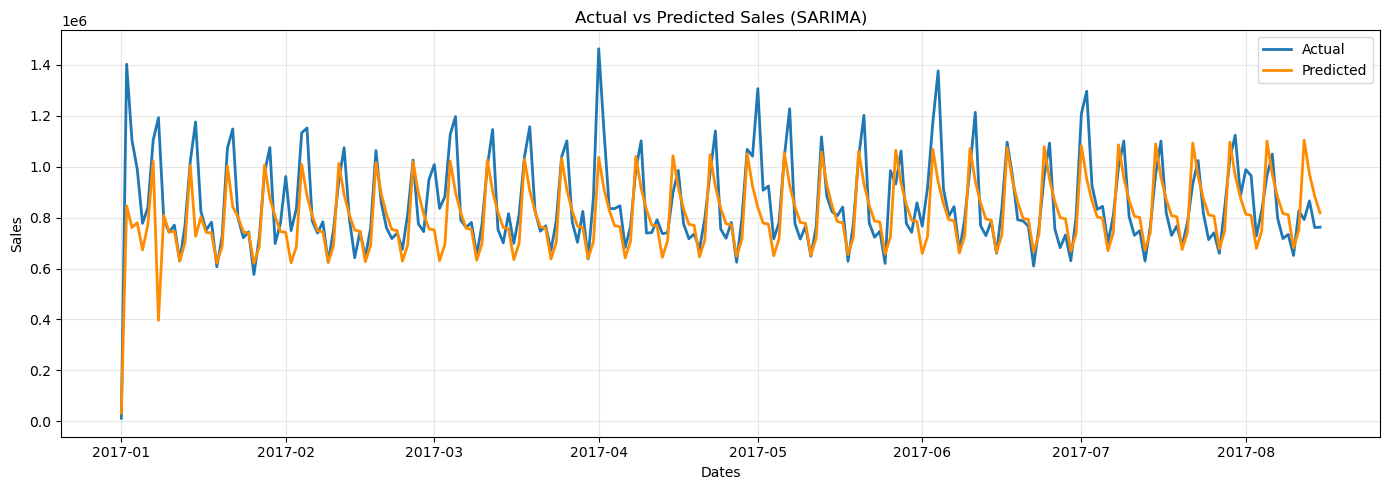

In [51]:
# Vẽ SARIMA 
plt.figure(figsize=(14,5))
plt.plot(y_test_real.index, y_test_real.values, label='Actual', linewidth=2)
plt.plot(y_test_real.index, yhat_test.values, label='Predicted', color='darkorange', linewidth=2)
plt.title('Actual vs Predicted Sales (SARIMA)')
plt.xlabel('Dates')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Mô hình 2: XGboost (Extreme Gradient Boosting)

In [52]:
# DMatrix là kiểu dữ liệu của XGBoost
dtrain = xgb.DMatrix(X_tr, label=y_tr_log)
dval = xgb.DMatrix(X_val, label=y_val_log)
dtest = xgb.DMatrix(X_test)

params_xgb = {
    "objective": "reg:squarederror", 
    "eval_metric": "rmse",
    "learning_rate": 0.05,
    "tree_method": "hist", 
    "max_depth": 8, 
    "min_child_weight": 5, 
    "gamma": 0.0, 
    "subsample": 0.8, 
    "colsample_bytree": 0.8, 
    "reg_lambda": 2.0, 
    "reg_alpha": 0.1, 
    "max_bin": 256, 
    "nthread": -1,
    "seed": 42,  
}

bst_xgb = xgb.train(
    params=params_xgb,
    dtrain=dtrain,
    num_boost_round = 3000,
    evals=[(dtrain, "train"), (dval, "val")],
    early_stopping_rounds = 300,
    verbose_eval = 200
)

pred_log = bst_xgb.predict(dtest, iteration_range=(0, bst_xgb.best_iteration + 1))
pred_xgb = np.expm1(pred_log)
pred_xgb = np.maximum(pred_xgb, 0)

[0]	train-rmse:2.57047	val-rmse:2.63334
[200]	train-rmse:0.36573	val-rmse:0.40720
[400]	train-rmse:0.35057	val-rmse:0.40110
[600]	train-rmse:0.34180	val-rmse:0.39872
[800]	train-rmse:0.33582	val-rmse:0.39702
[1000]	train-rmse:0.33106	val-rmse:0.39663
[1200]	train-rmse:0.32730	val-rmse:0.39584
[1400]	train-rmse:0.32380	val-rmse:0.39588
[1590]	train-rmse:0.32070	val-rmse:0.39603


In [53]:
# Đánh giá XGboost
rmse_xgb = np.sqrt(mean_squared_error(y_test, pred_xgb))
mae_xgb = mean_absolute_error(y_test, pred_xgb)
print(f"RMSE (XGBoost): {rmse_xgb:,.2f}")
print(f"MAE (XGBoost): {mae_xgb:,.2f}")

RMSE (XGBoost): 233.55
MAE (XGBoost): 54.21


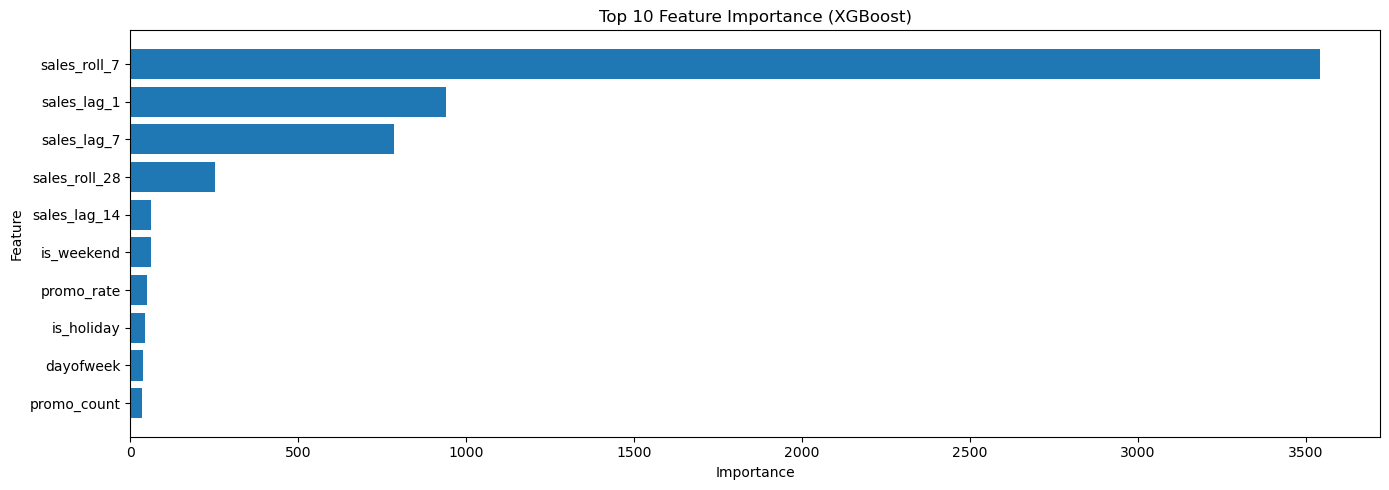

In [54]:
# Top 10 features XGBoost
importance = bst_xgb.get_score(importance_type='gain')
importance_df = pd.DataFrame({'Feature': list(importance.keys()), 'Importance': list(importance.values())})
importance_df = importance_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

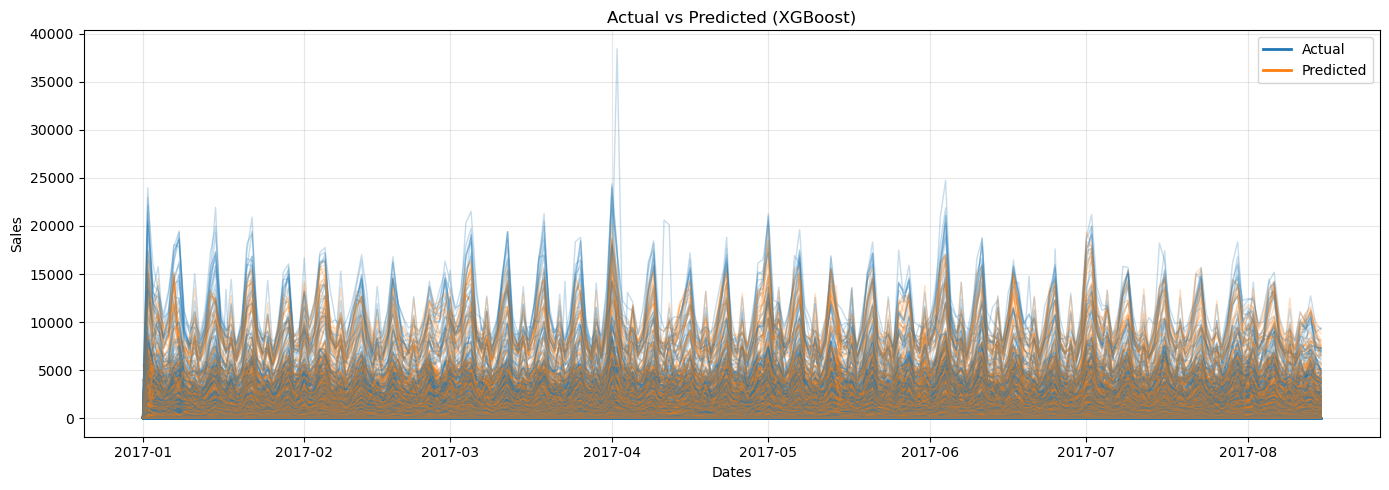

In [55]:
# Vẽ XGboost theo từng store x family
plot_df = test.copy()
plot_df['actual'] = y_test
plot_df['pred'] = pred_xgb
plot_df['date'] = pd.to_datetime(plot_df['date'])

plt.figure(figsize=(14,5))
for (s,f), g in plot_df.groupby(['store_nbr','family']):
    g = g.sort_values('date')
    plt.plot(g['date'], g['actual'], linewidth=1, alpha=0.25, color='tab:blue')
    plt.plot(g['date'], g['pred'], linewidth=1, alpha=0.25, color='tab:orange')

# tạo chú thích
actual_line = mlines.Line2D([], [], color='tab:blue', label='Actual', linewidth=2)
pred_line = mlines.Line2D([], [], color='tab:orange', label='Predicted', linewidth=2)

plt.legend(handles=[actual_line, pred_line], loc='upper right')

plt.title('Actual vs Predicted (XGBoost)')
plt.xlabel('Dates')
plt.ylabel('Sales') 
plt.grid(alpha=0.3) 
plt.tight_layout() 
plt.show()

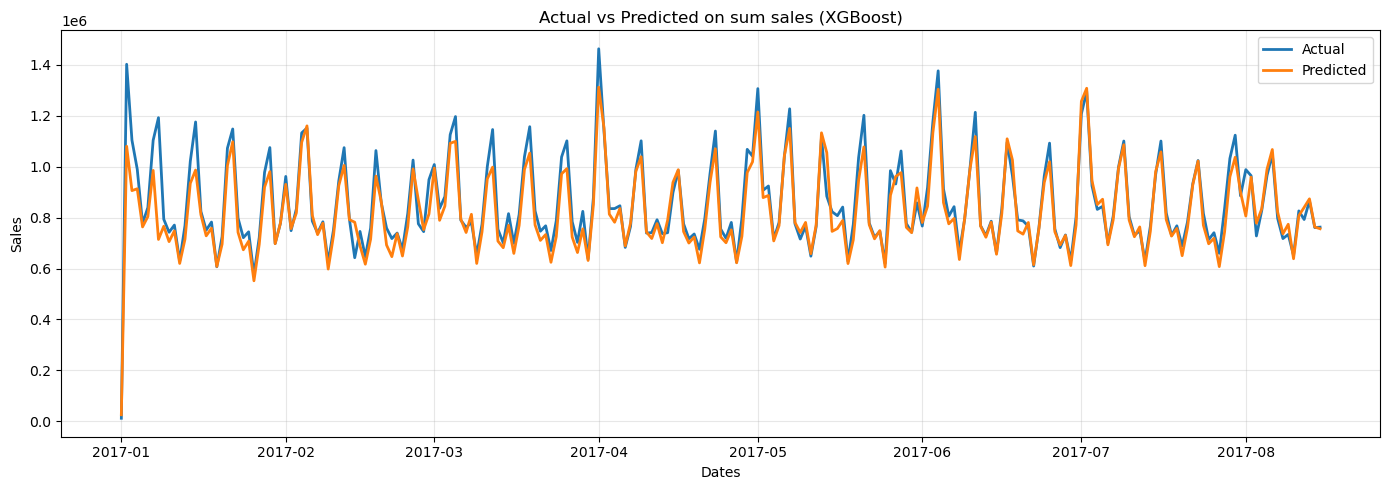

In [56]:
# Vẽ XGboost theo tổng
daily = (plot_df.groupby('date', as_index=False)[['actual','pred']].sum().sort_values('date'))
plt.figure(figsize=(14,5))
plt.plot(daily['date'], daily['actual'], label='Actual', linewidth=2)
plt.plot(daily['date'], daily['pred'], label='Predicted', linewidth=2)
plt.title('Actual vs Predicted on sum sales (XGBoost)')
plt.xlabel('Dates')
plt.ylabel('Sales')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Mô hình 3: LightGBM (Light Gradient Boosting Machine)

In [57]:
train_lgb = lgb.Dataset(X_tr, label=y_tr_log)
val_lgb = lgb.Dataset(X_val, label=y_val_log, reference=train_lgb)

params_lgb = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 127,            
    "min_data_in_leaf": 300,     
    "feature_fraction": 0.8,
    "feature_fraction_bynode": 0.9, 
    "bagging_fraction": 0.8,
    "bagging_freq": 5,           
    "lambda_l1": 0.05,
    "lambda_l2": 1.5,
    "min_gain_to_split": 0.02,
    "max_bin": 255,
    "num_threads": -1,
    "seed": 42,
    "first_metric_only": True
}

bst_lgb = lgb.train(
    params=params_lgb,
    train_set=train_lgb,
    valid_sets=[train_lgb, val_lgb],
    valid_names=["train","val"],
    num_boost_round=3000,
    callbacks=[early_stopping(stopping_rounds=200), log_evaluation(period=200)]
)

pred_lgb = np.expm1(bst_lgb.predict(X_test, num_iteration=bst_lgb.best_iteration))
pred_lgb = np.maximum(pred_lgb, 0)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.079382 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4644
[LightGBM] [Info] Number of data points in the train set: 2544696, number of used features: 35
[LightGBM] [Info] Start training from score 2.808163
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 0.370913	val's rmse: 0.413651
[400]	train's rmse: 0.358117	val's rmse: 0.407245
[600]	train's rmse: 0.351536	val's rmse: 0.40425
[800]	train's rmse: 0.346739	val's rmse: 0.402392
[1000]	train's rmse: 0.343183	val's rmse: 0.401534
[1200]	train's rmse: 0.340089	val's rmse: 0.400722
[1400]	train's rmse: 0.337411	val's rmse: 0.400494
[1600]	train's rmse: 0.334884	val's rmse: 0.400182
[1800]	train's rmse: 0.332286	val's rmse: 0.400051
[2000]	train's rmse: 0.329897	val's rmse: 0.399859
[2200]	train's rmse: 0.32

In [58]:
# Đánh giá LightGBM
rmse_lgb = np.sqrt(mean_squared_error(y_test, pred_lgb))
mae_lgb = mean_absolute_error(y_test, pred_lgb)
print(f"RMSE (LightGBM): {rmse_lgb:,.2f}")
print(f"MAE (LightGBM): {mae_lgb:,.2f}")

RMSE (LightGBM): 236.00
MAE (LightGBM): 54.51


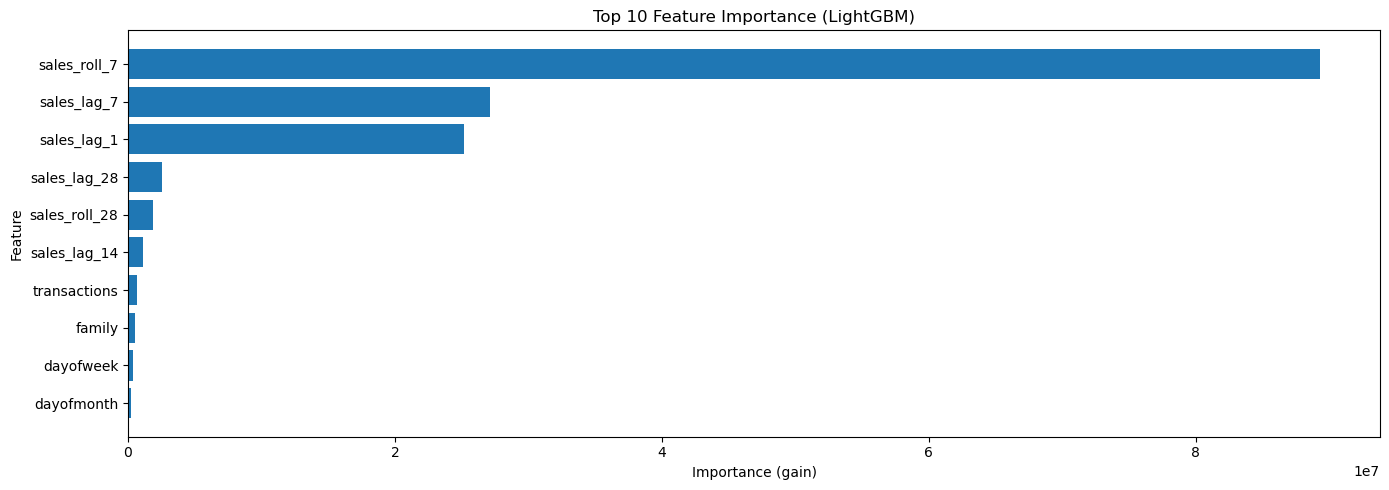

In [59]:
# Top 10 features LightGBM
feat_names = bst_lgb.feature_name()
feat_gain = bst_lgb.feature_importance(importance_type='gain')
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': feat_gain})
imp_top10 = imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.barh(imp_top10['Feature'][::-1], imp_top10['Importance'][::-1])
plt.xlabel('Importance (gain)')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance (LightGBM)')
plt.tight_layout()
plt.show()

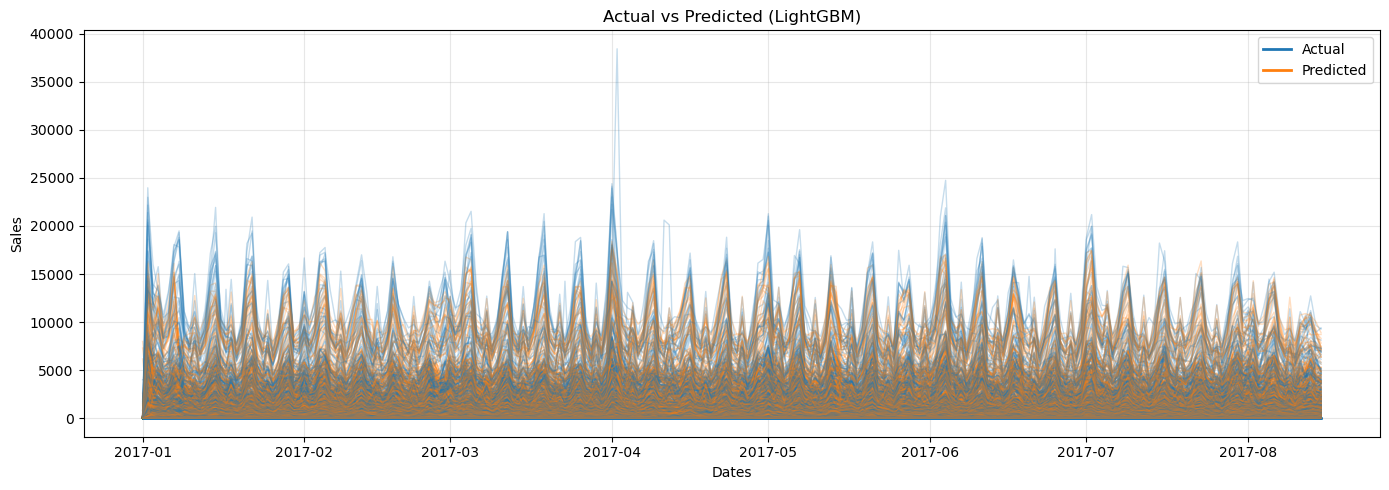

In [60]:
# Vẽ LightGBM theo từng store x family
plot_df = test.copy()
plot_df['actual'] = y_test
plot_df['pred'] = pred_lgb
plot_df['date'] = pd.to_datetime(plot_df['date'])

plt.figure(figsize=(14,5))
for (s,f), g in plot_df.groupby(['store_nbr','family']):
    g = g.sort_values('date')
    plt.plot(g['date'], g['actual'], linewidth=1, alpha=0.25, color='tab:blue')
    plt.plot(g['date'], g['pred'], linewidth=1, alpha=0.25, color='tab:orange')

# tạo chú thích
actual_line = mlines.Line2D([], [], color='tab:blue', label='Actual', linewidth=2)
pred_line = mlines.Line2D([], [], color='tab:orange', label='Predicted', linewidth=2)
plt.legend(handles=[actual_line, pred_line], loc='upper right')

plt.title('Actual vs Predicted (LightGBM)')
plt.xlabel('Dates')
plt.ylabel('Sales') 
plt.grid(alpha=0.3) 
plt.tight_layout() 
plt.show()

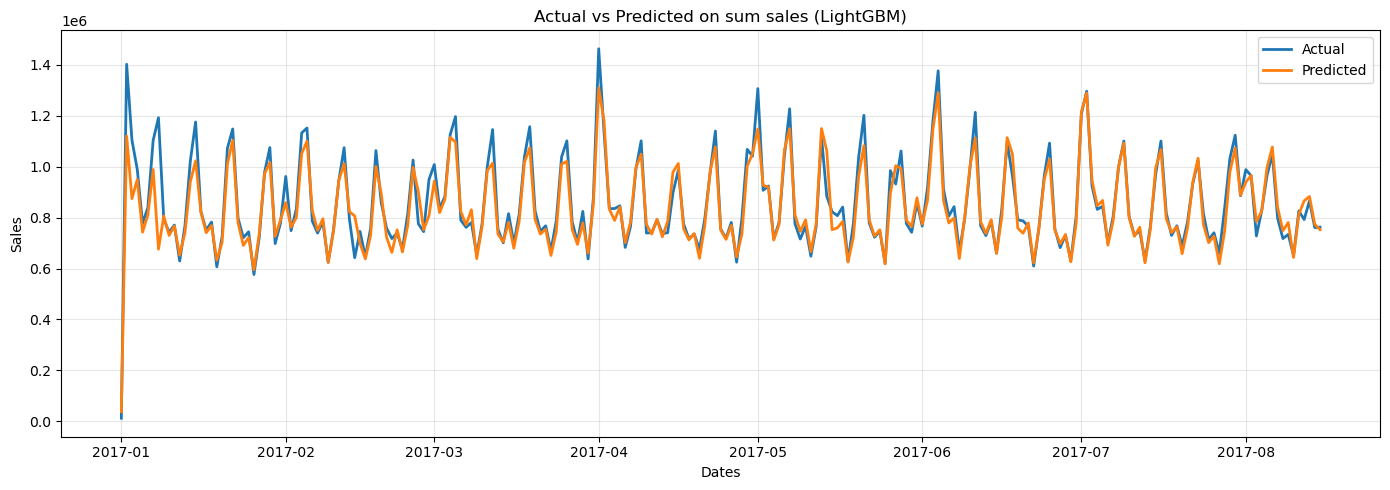

In [61]:
# Vẽ LightGBM theo tổng
daily = (plot_df.groupby('date', as_index=False)[['actual','pred']].sum().sort_values('date'))
plt.figure(figsize=(14,5))
plt.plot(daily['date'], daily['actual'], label='Actual', linewidth=2)
plt.plot(daily['date'], daily['pred'], label='Predicted', linewidth=2)
plt.legend()
plt.title('Actual vs Predicted on sum sales (LightGBM)')
plt.xlabel('Dates')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Mô hình 4: CatBoost (Categorical Boosting)

In [62]:
# chỉ số cột categorical
cat_cols = ['store_nbr','family','city','state','type','cluster']
cat_idx = [X_tr.columns.get_loc(c) for c in cat_cols]
assert list(X_tr.columns) == list(X_val.columns) == list(X_test.columns)

# đảm bảo dtype int cho các cột categorical đã encode
for c in cat_cols:
    X_tr[c] = X_tr[c].astype(int)
    X_val[c] = X_val[c].astype(int)
    X_test[c] = X_test[c].astype(int)

# Pool
train_pool = Pool(X_tr, y_tr_log, cat_features=cat_idx)
val_pool = Pool(X_val, y_val_log, cat_features=cat_idx)

cat_model = CatBoostRegressor(
    iterations=5000,
    learning_rate=0.05,
    depth=8,
    l2_leaf_reg=8,
    random_strength=1.5,
    bootstrap_type="Bayesian",
    bagging_temperature=1.0,
    rsm=0.8,
    leaf_estimation_method="Newton",
    leaf_estimation_iterations=12,
    one_hot_max_size=32,
    max_ctr_complexity=2,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    od_type="Iter",
    od_wait=300,
    verbose=500,
    allow_writing_files=False
)

cat_model.fit(train_pool, eval_set=val_pool, use_best_model=True)

# Predict 
pred_log = cat_model.predict(Pool(X_test, cat_features=cat_idx))
pred_cat = np.expm1(pred_log)
pred_cat = np.maximum(pred_cat, 0)

0:	learn: 2.5746293	test: 2.6372395	best: 2.6372395 (0)	total: 1.04s	remaining: 1h 26m 24s
500:	learn: 0.3704007	test: 0.4168650	best: 0.4168650 (500)	total: 6m 26s	remaining: 57m 51s
1000:	learn: 0.3571761	test: 0.4113905	best: 0.4113905 (1000)	total: 12m 48s	remaining: 51m 8s
1500:	learn: 0.3501867	test: 0.4076990	best: 0.4076925 (1495)	total: 19m 10s	remaining: 44m 41s
2000:	learn: 0.3456684	test: 0.4055466	best: 0.4055426 (1994)	total: 25m 31s	remaining: 38m 15s
2500:	learn: 0.3421373	test: 0.4044489	best: 0.4044489 (2500)	total: 32m 1s	remaining: 31m 59s
3000:	learn: 0.3393505	test: 0.4035096	best: 0.4035096 (3000)	total: 38m 28s	remaining: 25m 38s
3500:	learn: 0.3371472	test: 0.4028343	best: 0.4028159 (3488)	total: 44m 56s	remaining: 19m 14s
4000:	learn: 0.3351123	test: 0.4023900	best: 0.4023872 (3997)	total: 51m 29s	remaining: 12m 51s
4500:	learn: 0.3332045	test: 0.4021719	best: 0.4021699 (4498)	total: 58m 3s	remaining: 6m 26s
Stopped by overfitting detector  (300 iterations wai

In [63]:
# Đánh giá CatBoost
rmse_cat = np.sqrt(mean_squared_error(y_test, pred_cat))
mae_cat = mean_absolute_error(y_test, pred_cat)
print(f"RMSE (CatBoost): {rmse_cat:,.2f}")
print(f"MAE (CatBoost): {mae_cat:,.2f}")

RMSE (CatBoost): 249.47
MAE (CatBoost): 55.96


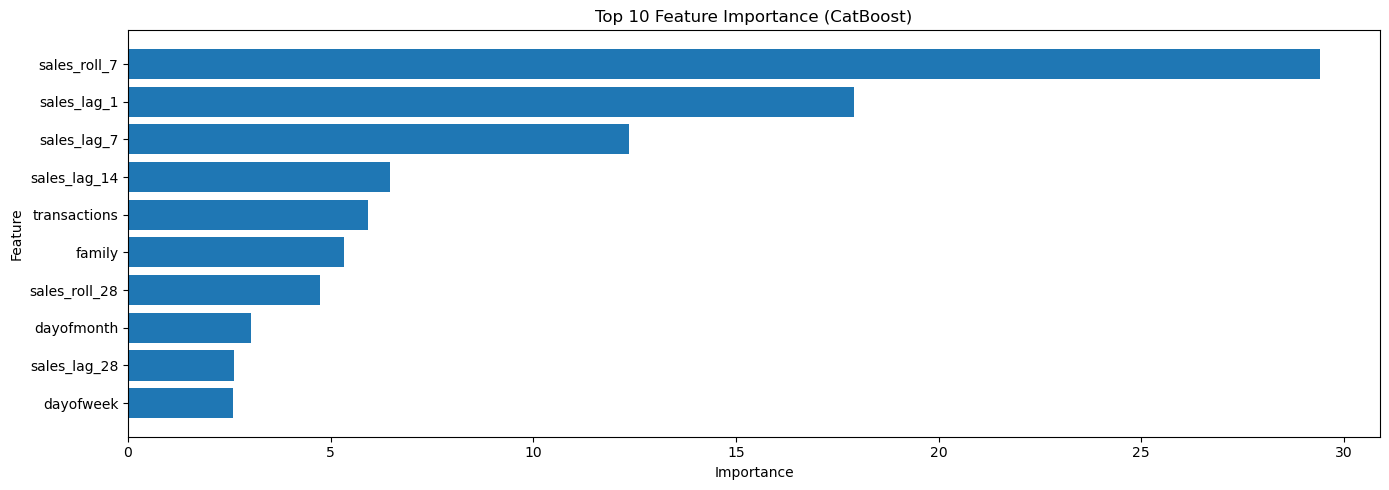

In [64]:
# Top 10 features CatBoost
feat_importance = cat_model.get_feature_importance()
feat_names = X_tr.columns
imp_df = pd.DataFrame({'Feature': feat_names, 'Importance': feat_importance})
imp_top10 = imp_df.sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(14,5))
plt.barh(imp_top10['Feature'][::-1], imp_top10['Importance'][::-1])
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Feature Importance (CatBoost)')
plt.tight_layout()
plt.show()

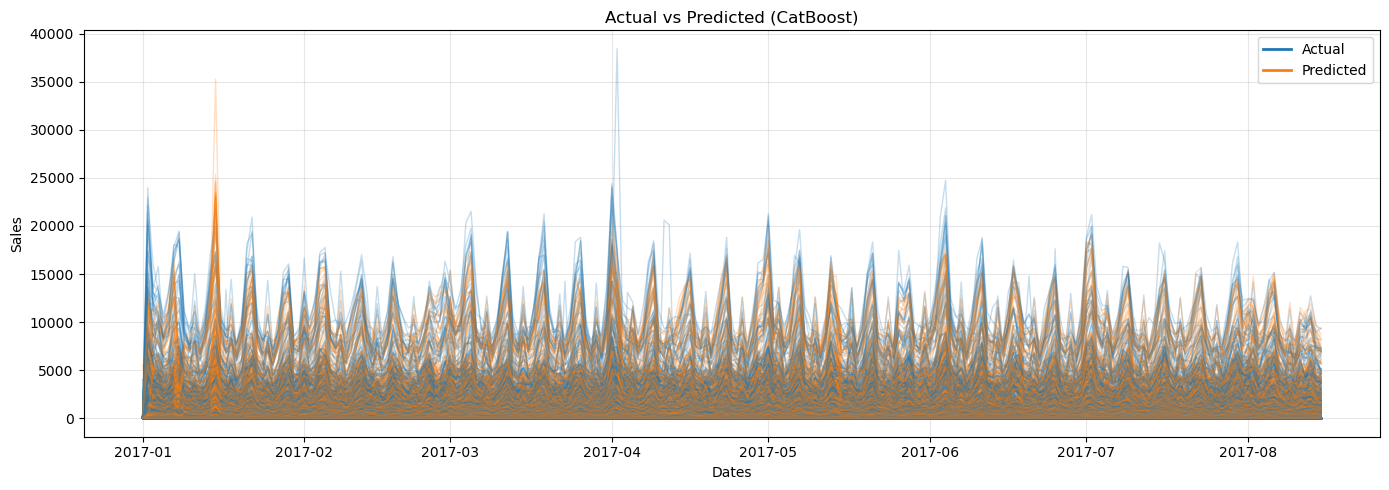

In [65]:
# Vẽ CatBoost theo từng store x family
plot_df = test.copy()
plot_df['actual'] = y_test
plot_df['pred'] = pred_cat
plot_df['date'] = pd.to_datetime(plot_df['date'])

plt.figure(figsize=(14,5))
for (s,f), g in plot_df.groupby(['store_nbr','family']):
    g = g.sort_values('date')
    plt.plot(g['date'], g['actual'], linewidth=1, alpha=0.25, color='tab:blue')
    plt.plot(g['date'], g['pred'], linewidth=1, alpha=0.25, color='tab:orange')

# tạo chú thích
actual_line = mlines.Line2D([], [], color='tab:blue', label='Actual', linewidth=2)
pred_line = mlines.Line2D([], [], color='tab:orange', label='Predicted', linewidth=2)

plt.legend(handles=[actual_line, pred_line], loc='upper right')

plt.title('Actual vs Predicted (CatBoost)')
plt.xlabel('Dates')
plt.ylabel('Sales') 
plt.grid(alpha=0.3) 
plt.tight_layout() 
plt.show()

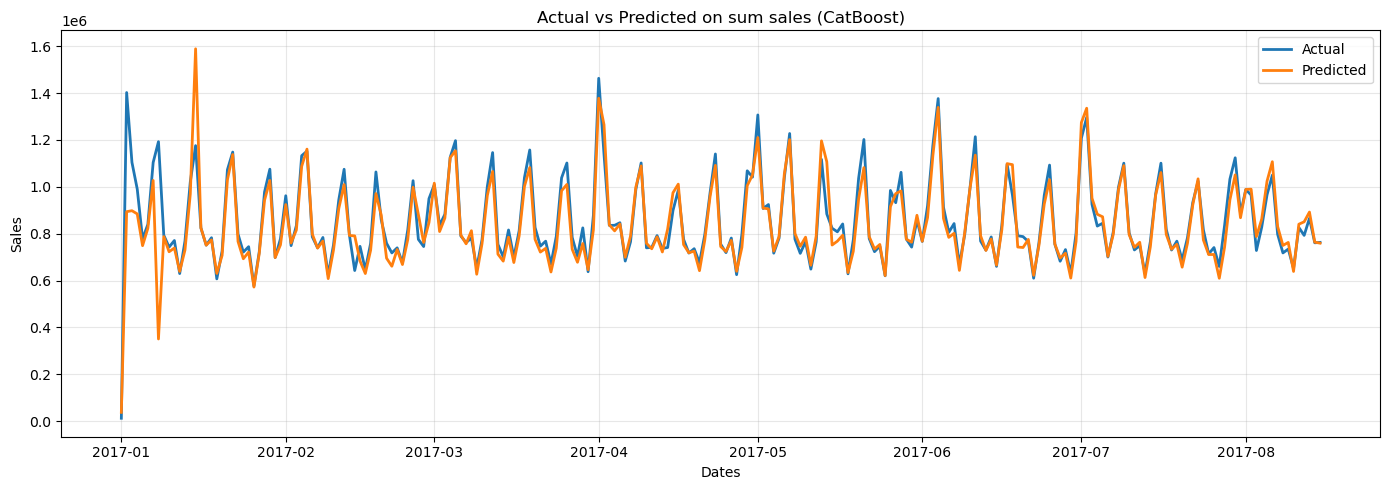

In [66]:
# Vẽ CatBoost theo tổng
daily = (plot_df.groupby('date', as_index=False)[['actual','pred']].sum().sort_values('date'))
plt.figure(figsize=(14,5))
plt.plot(daily['date'], daily['actual'], label='Actual', linewidth=2)
plt.plot(daily['date'], daily['pred'], label='Predicted', linewidth=2)
plt.legend()
plt.title('Actual vs Predicted on sum sales (CatBoost)')
plt.xlabel('Dates')
plt.ylabel('Sales')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Bảng so sánh kết quả các mô hình Boosting (Machine Learning)

In [67]:
# Tạo bảng kết quả
results = pd.DataFrame({
    'Model': ['XGBoost', 'LightGBM', 'CatBoost'],
    'RMSE':[rmse_xgb, rmse_lgb, rmse_cat],
    'MAE': [mae_xgb, mae_lgb, mae_cat]
})

# Sắp xếp theo RMSE tăng dần (mô hình tốt nhất ở trên)
results = results.sort_values(by='RMSE').reset_index(drop=True)

# In bảng kết quả
display(results.style.hide(axis='index').format({'RMSE': '{:.2f}', 'MAE': '{:.2f}'}))

Model,RMSE,MAE
XGBoost,233.55,54.21
LightGBM,236.00,54.51
CatBoost,249.47,55.96


# Minh hoạ kết quả dự báo

In [68]:
# Minh hoạ kết quả dự báo của trong ngày cuối cùng của bộ test
test_out = test.copy()
test_out["predicted_sales"] = pred_xgb

# Dùng encoder đã lưu trong dict encoders để giải mã lại giá trị gốc
test_out["store_nbr"] = encoders["store_nbr"].inverse_transform(test_out["store_nbr"].astype(int))
test_out["family"] = encoders["family"].inverse_transform(test_out["family"].astype(int))

last_date = test_out["date"].max()

cols_view = ["store_nbr", "family", "sales", "predicted_sales"]
last_day = (test_out.loc[test_out["date"] == last_date, cols_view]
            .sort_values(by=["store_nbr", "family"]))

print(f"Ngày cuối cùng của bộ test: {last_date}")
print(last_day.head(33).to_string(index=False, formatters={"sales": "{:.2f}".format, 
                                                           "predicted_sales": "{:.2f}".format}))

Ngày cuối cùng của bộ test: 2017-08-15 00:00:00
store_nbr                     family   sales predicted_sales
        1                 AUTOMOTIVE    4.00            3.54
        1                  BABY CARE    0.00            0.00
        1                     BEAUTY    4.00            3.84
        1                  BEVERAGES 1942.00         2252.39
        1                      BOOKS    0.00            0.09
        1               BREAD/BAKERY  329.54          354.97
        1                CELEBRATION   21.00           10.15
        1                   CLEANING  703.00          708.98
        1                      DAIRY  602.00          662.62
        1                       DELI  116.40          127.36
        1                       EGGS  131.00          133.59
        1               FROZEN FOODS   89.00          125.91
        1                  GROCERY I 2508.00         2828.59
        1                 GROCERY II   13.00           22.01
        1                   HARDWARE 

# Lưu models

In [70]:
# Tạo thư mục models (nếu chưa có)
os.makedirs("models", exist_ok=True)

# Lưu model
joblib.dump(bst_xgb,"models/xgb_model.pkl")
# joblib.dump(bst_lgb,"models/lgb_model.pkl")
# joblib.dump(cat_model,"models/cat_model.pkl")

print("Đã lưu thành công")

Đã lưu thành công
